In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.fft import fftshift,fftfreq
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True

In [2]:
N = 192


In [26]:
datapath = lambda f_corr,N_b,ti,tf: f"/mnt/pfs/rajarshi.chattopadhyay/codes/boussinesq/data/bsnq/f_{f_corr:.1f}_Nb_{N_b:.1f}/tide_test_new_forced_True/N_{N}_Re_18530201888518408977621450752.0/e_omg_kh_kz_ti_{ti:.3f}_tf_{tf:.3f}.hdf5"

In [27]:
times_o = np.arange(0,31.4,0.1)
Ntimes = len(times_o)
freqs = 2*np.pi/(times_o[-1] - times_o[0])*fftfreq(Ntimes,1./Ntimes)
freqs_pos = np.abs(2*np.pi/(times_o[-1] - times_o[0])*fftfreq(Ntimes,1./Ntimes)[:Ntimes//2 + 1])
domega = freqs[1] - freqs[0]
Kz = Kh = np.arange(0,N//2+1)
shells = np.arange(-0.5,N//2+1)
shells[0] = 0.
omg,kh,kz = np.meshgrid(freqs,Kh,Kz,indexing = 'ij')
omg_shells = np.array(list(freqs_pos - 0.5*freqs_pos[1]) + [freqs_pos[-1] + 0.5*freqs_pos[1]])
freqs = fftshift(freqs)

In [28]:
def get_pos_omg(x):
    return np.histogramdd(np.concatenate((np.abs(omg).ravel()[:,None],kh.ravel()[:,None],kz.ravel()[:,None]),axis = 1),bins = [omg_shells,shells,shells],weights = x.ravel())[0]

In [29]:
omg_kh_kz = []
omg_pos_kh_kz = []
f_corrs = [1]
N_b = 10
for i,f_corr in enumerate(f_corrs):
    ti = 0.0
    tf = 31.4/f_corr
    with h5py.File(datapath(f_corr,N_b,ti,tf),'r') as f:
        omg_kh_kz.append(np.sum(f['e_u_omg_kh_kz'],axis = 1)  + f['e_b_omg_kh_kz'][:])
    print(np.sum(omg_kh_kz[i]))
    omg_kh_kz[i] /= np.sum(omg_kh_kz[i])
    omg_pos_kh_kz.append(get_pos_omg(omg_kh_kz[i]))
        
omg_kh_kz = np.array(omg_kh_kz)

5.896464476786094e+17


In [30]:
omg_disp = lambda f,kh,kz,Nb = N_b : ((N_b**2 * kh**2 + f*kz**2)/(kh**2 + kz**2 +1e-16))**0.5/f

In [31]:
norm = LogNorm(vmin = 1e-6,vmax = 1)

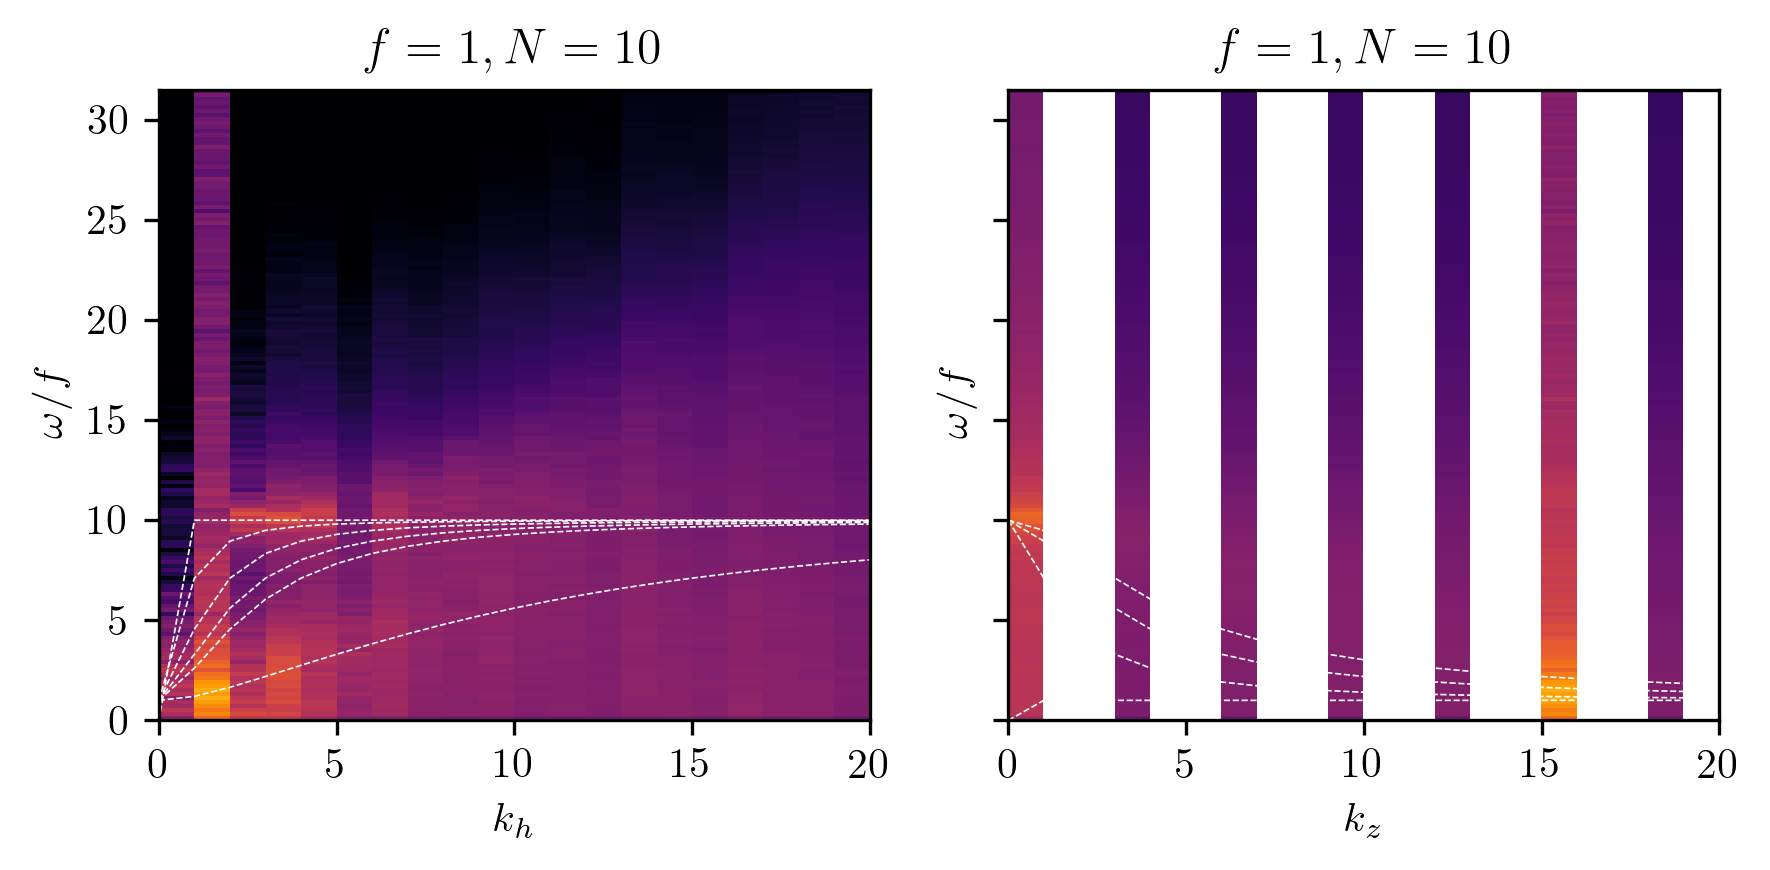

In [32]:
fig,ax = plt.subplots(1,2,figsize = (6,3),dpi = 300,sharey = True)
# for i in range(2):
ax[0].imshow(omg_pos_kh_kz[i].sum(axis = -1),extent = [0,N//2 + 1, freqs_pos[0],freqs_pos[-1]],origin = 'lower',aspect = 'auto',cmap = "inferno",norm = norm)
for kkz in [0,1,2,3,4,15]:
    ax[0].plot(Kh,omg_disp(f_corrs[i],Kh,kkz),color = 'white',ls = '--',lw = 0.4)
# ax[i].set_ylim(0,None)
ax[0].set_xlabel(r'$k_h$')
ax[1].imshow(omg_pos_kh_kz[i].sum(axis = 1),extent = [0,N//2 + 1, freqs_pos[0],freqs_pos[-1]],origin = 'lower',aspect = 'auto',cmap = "inferno",norm = norm)
for kkh in range(4):
    ax[1].plot(Kz,omg_disp(f_corrs[i],kkh,Kz),color = 'white',ls = '--',lw = 0.4)
# ax[i].set_ylim(0,None)
ax[1].set_xlabel(r'$k_z$')
for axs in ax:
    axs.set_title(f"$f = {f_corrs[i]}, N = {N_b}$")
    axs.set_ylabel(r'$\omega/f$')
    axs.set_xlim(0,20)
fig.tight_layout()

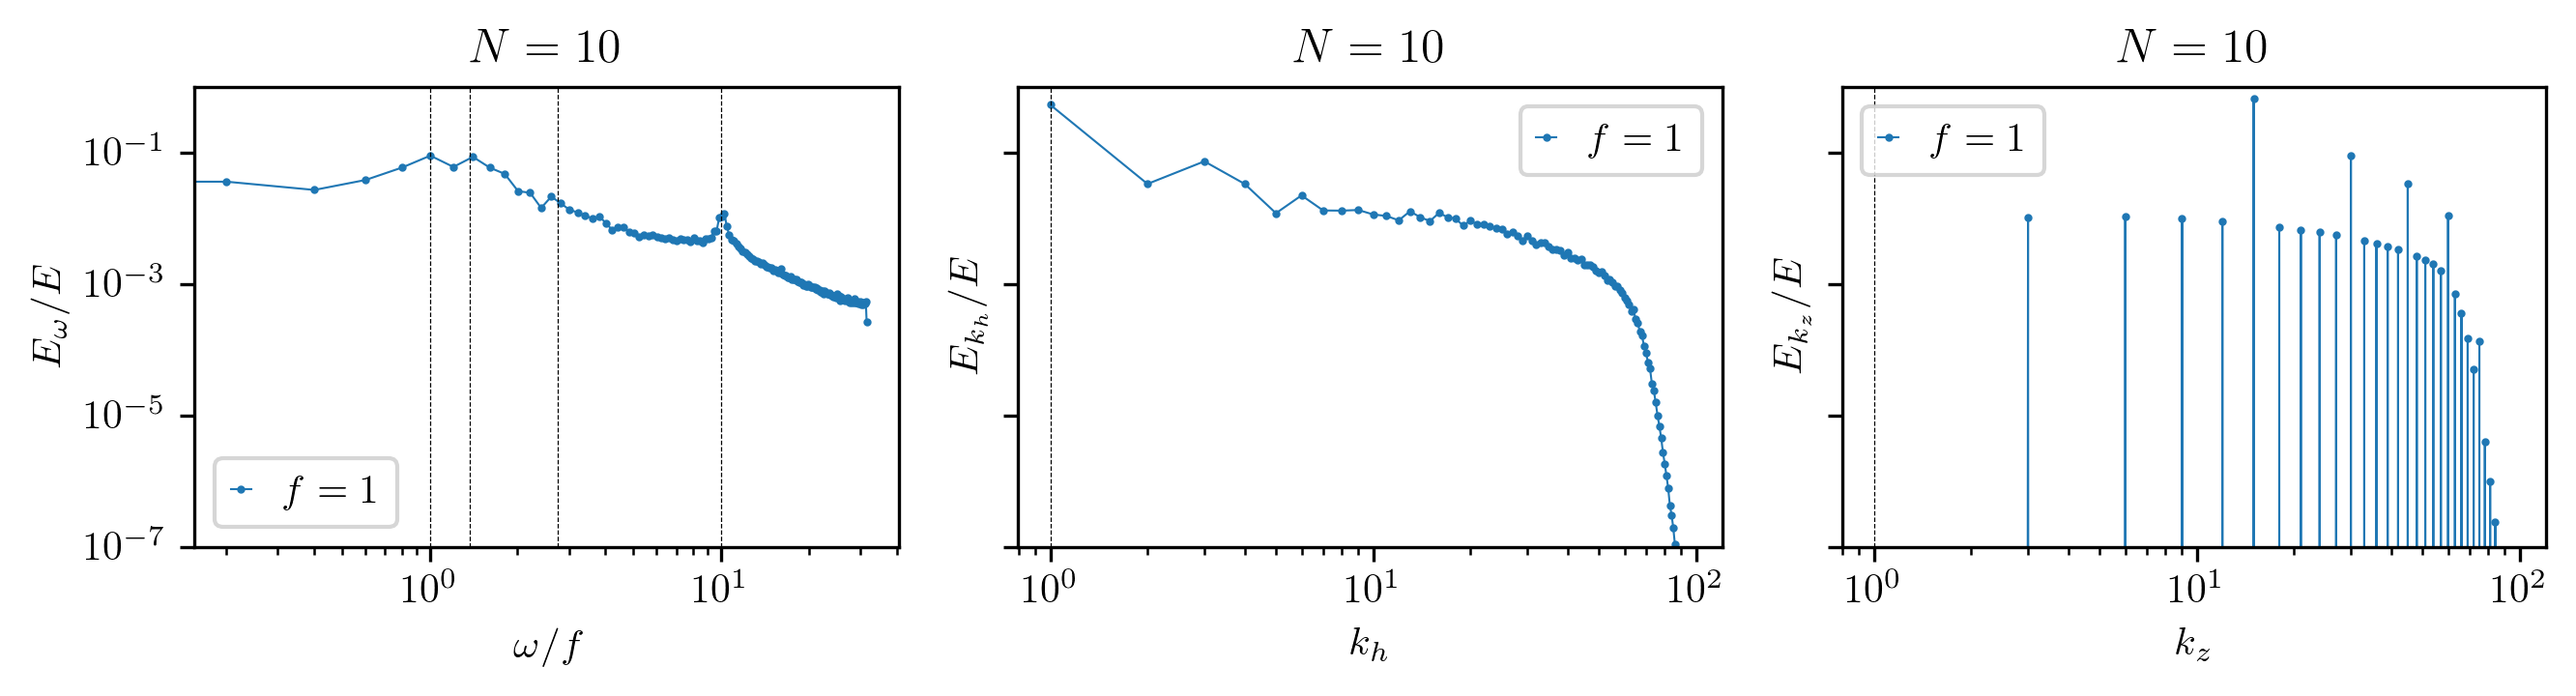

In [34]:
fig,axs = plt.subplots(1,3,figsize = (9,2.5),dpi = 300,sharey = True)

freqs
for i in range(len(f_corrs)):
    E = omg_kh_kz[i].sum()
    axs[0].plot(freqs_pos,omg_pos_kh_kz[i].sum(axis = (1,2))/E,'.-',ms = 2,lw = 0.5,label = f"$f = {f_corrs[i]}$")
    axs[1].plot(range(1,N//2 + 1),omg_pos_kh_kz[i].sum(axis = (0,2))[1:]/E,'.-',ms = 2,lw = 0.5,label = f"$f = {f_corrs[i]}$")
    axs[2].plot(np.arange(N//2 + 1),omg_pos_kh_kz[i].sum(axis = (0,1))/E,'.-',ms = 2,lw = 0.5,label = f"$f = {f_corrs[i]}$")

    # ax.set_xscale('symlog', base = 2,linthresh = freqs_pos[1],linscale=0.1)
    
xlabels = [r'$\omega/f$',r'$k_h$',r'$k_z$']
ylabels = ['{\omega}','{k_h}','{k_z}']
for i,ax in enumerate(axs):
    ax.set_xscale('log')
    ax.set_yscale('log')
    # ax.set_xlim(freqs_pos[1],None)
    # ax.set_ylim(0,None)
    ax.set_xlabel(xlabels[i])
    ax.set_title(f"$N = {N_b}$")
    # ax.set_ylabel(fr"$E_{ylabels[i]}/E$")
    ax.set_ylabel(fr"$E_{ylabels[i]}/E$")
    ax.legend(handlelength=0.5)
    ax.set_ylim(1e-7,1)
freqlines = [f_corrs[0],N_b,omg_disp(f_corrs[0],2**0.5,15),2*omg_disp(f_corrs[0],2**0.5,15)]
for f in freqlines:
    axs[0].axvline(f,ls = '--',color = 'k',lw = 0.3)
khs = [1]
kzs = [1]
for f in khs:
    axs[1].axvline(f,ls = '--',color = 'k',lw = 0.3)
for f in kzs:
    axs[2].axvline(f,ls = '--',color = 'k',lw = 0.3)

fig.tight_layout()
# axs[-1].set_xscale('linear')

In [11]:
omg_pos_kh_kz[0].sum(axis = (0,1))/E

array([4.98451758e-02, 0.00000000e+00, 0.00000000e+00, 7.98861119e-04,
       0.00000000e+00, 0.00000000e+00, 6.74084937e-04, 0.00000000e+00,
       0.00000000e+00, 6.85637599e-04, 0.00000000e+00, 0.00000000e+00,
       8.50907976e-04, 0.00000000e+00, 0.00000000e+00, 7.58596638e-01,
       0.00000000e+00, 0.00000000e+00, 7.44161695e-04, 0.00000000e+00,
       0.00000000e+00, 5.69931121e-04, 0.00000000e+00, 0.00000000e+00,
       5.37096524e-04, 0.00000000e+00, 0.00000000e+00, 6.20487941e-04,
       0.00000000e+00, 0.00000000e+00, 1.25769655e-01, 0.00000000e+00,
       0.00000000e+00, 5.33031144e-04, 0.00000000e+00, 0.00000000e+00,
       4.18982442e-04, 0.00000000e+00, 0.00000000e+00, 3.93003673e-04,
       0.00000000e+00, 0.00000000e+00, 4.48999102e-04, 0.00000000e+00,
       0.00000000e+00, 4.23158357e-02, 0.00000000e+00, 0.00000000e+00,
       3.65438827e-04, 0.00000000e+00, 0.00000000e+00, 2.76789187e-04,
       0.00000000e+00, 0.00000000e+00, 2.46452919e-04, 0.00000000e+00,
      

In [12]:
data = np.load("/mnt/pfs/rajarshi.chattopadhyay/codes/boussinesq/data/bsnq/f_1.0_Nb_20.0/tide_forced_True/N_192_Re_18530201888518408977621450752.0/time_13.200/Fields_k_42.npz")
data["uk"][0,0]

array([  466.19971042+1692.94090789j,     0.           +0.j        ,
           0.           +0.j        ,  3527.19617636+4519.09304149j,
           0.           +0.j        ,     0.           +0.j        ,
        1658.15471846-2741.78987965j,     0.           +0.j        ,
           0.           +0.j        ,  -904.41703543-1134.58190656j,
           0.           +0.j        ,     0.           +0.j        ,
       -1356.73619336+3918.65283427j,     0.           +0.j        ,
           0.           +0.j        ,  -645.23082431 +233.12755083j,
           0.           +0.j        ,     0.           +0.j        ,
       -1454.81446902 +305.22961941j,     0.           +0.j        ,
           0.           +0.j        ,  -488.8750614 +3560.89226492j,
           0.           +0.j        ,     0.           +0.j        ,
        2458.00130135 +693.11689369j,     0.           +0.j        ,
           0.           +0.j        ,   867.61644711-1686.33632211j,
           0.           +0.j      

In [14]:
import os
rank = 0
paths = f"/mnt/pfs/rajarshi.chattopadhyay/codes/boussinesq/data/bsnq/f_{f_corrs[0]:.1f}_Nb_{N_b:.1f}/tide_forced_True/N_{N}_Re_18530201888518408977621450752.0/last/"

Np = N
load_num_slabs = len([x for x in os.listdir(paths) if "Fields_k" in str(x) and ".npz" in str(x)])
data_per_rank = N//load_num_slabs
rank_data = range(rank*Np,(rank + 1)*Np) # The rank contains these slices 
slab_old = np.inf
uk = np.zeros((3,N,N,N//2 + 1), dtype = np.complex128())
bk = np.zeros((N,N,N//2 + 1), dtype = np.complex128())
for lidx,j in enumerate(rank_data):
    slab = j//data_per_rank
    idx = j%data_per_rank
    
    # print(f"Rank {rank} is loading slab {slab} and idx {idx}")
    
    """Loading the truncated data"""
    if slab_old != slab:  
        Field = np.load(paths + f"Fields_k_{slab}.npz")

    uk[0,:,lidx] = Field['uk'][:,idx]
    uk[1,:,lidx] = Field['vk'][:,idx]
    uk[2,:,lidx] = Field['wk'][:,idx]
    bk[:,lidx] = Field['bk'][:,idx]

In [24]:
from scipy.fft import irfftn,fftfreq


Kx = Ky = fftfreq(N,1/N)
kx,ky,kz = np.meshgrid(Kx,Ky,Kz, indexing = 'ij')
zeta = irfftn(1j*kx*uk[1]- 1j*ky*uk[0])

In [26]:
u = irfftn(uk,axes = (-3,-2,-1))

In [28]:
zeta.mean(),zeta.std()

(np.float64(5.589664533703045e-18), np.float64(6.8562669241797245))